In [13]:
# 4-1. 인구현황 데이터 분석
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

population_raw = pd.read_csv('data/인구현황.csv', encoding='utf-8-sig')

national_per_household = population_raw.loc[
    population_raw['행정기관'] == '전국',
    '세대당 인구',
].iloc[0]

population = population_raw[population_raw['행정기관'] != '전국'].copy()

population['남초여초'] = population['남여 비율'].apply(
    lambda ratio: '남초' if ratio > 1 else ('여초' if ratio < 1 else '동일')
)

print('데이터 크기:', population.shape)
population.head()

데이터 크기: (17, 9)


,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율,남초여초
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93,여초
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95,여초
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96,여초
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00,동일
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97,여초


In [14]:
# 4-1-1. 지역별 총인구수 Top5
total_top5 = population.sort_values('총인구수', ascending=False).head(5)
display(total_top5[['행정기관', '총인구수']])

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


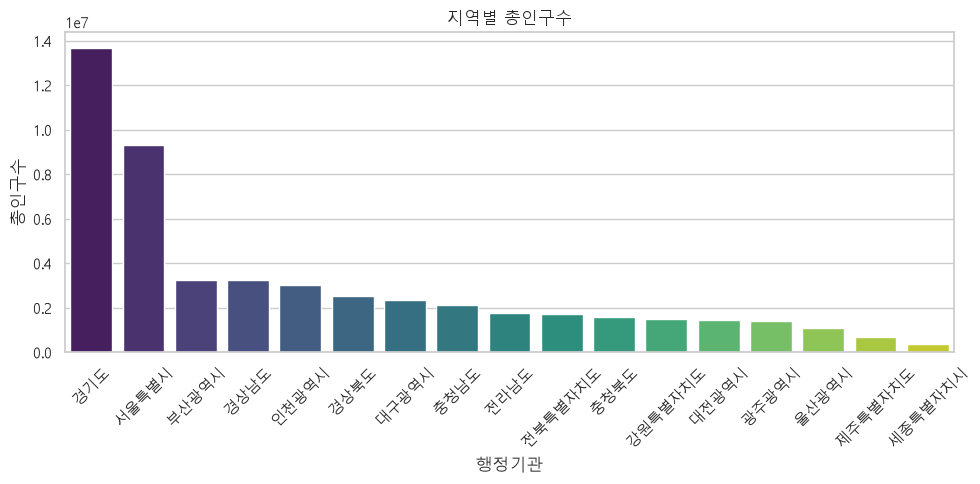

In [15]:
# 4-1-1. 지역별 총인구수 plot
plot_data = population.sort_values('총인구수', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x='행정기관', y='총인구수', hue='행정기관', palette='viridis', legend=False)
plt.title('지역별 총인구수')
plt.xlabel('행정기관')
plt.ylabel('총인구수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# 4-1-2. 세대당 인구수 높은 지역 Top5
per_household_top5 = population.sort_values('세대당 인구', ascending=False).head(5)
display(per_household_top5[['행정기관', '세대당 인구']])

,행정기관,세대당 인구
8,세종특별자치시,2.39
9,경기도,2.26
7,울산광역시,2.22
4,인천광역시,2.20
3,대구광역시,2.14


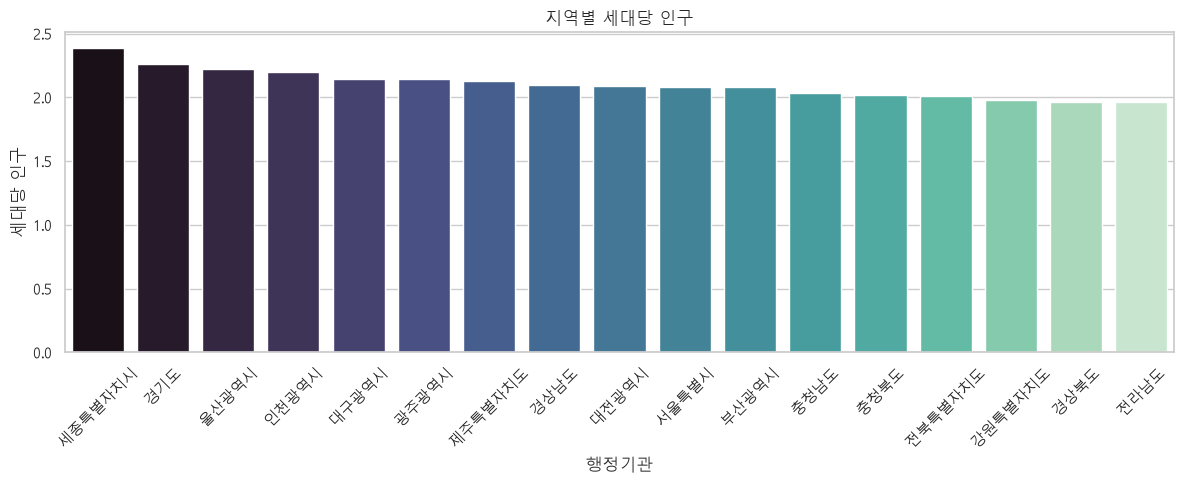

In [17]:
# 4-1-2. 지역별 세대당 인구 Plot
plot_data = population.sort_values('세대당 인구', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x='행정기관', y='세대당 인구', hue='행정기관', palette='mako', legend=False)
plt.title('지역별 세대당 인구')
plt.xlabel('행정기관')
plt.ylabel('세대당 인구')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# 4-1-3. 남녀 비율 분석
gender_ratio = population[['행정기관', '남여 비율']].sort_values('남여 비율', ascending=False)
display(gender_ratio)

,행정기관,남여 비율
7,울산광역시,1.06
12,충청남도,1.05
11,충청북도,1.04
14,전라남도,1.02
15,경상북도,1.02
16,경상남도,1.02
10,강원특별자치도,1.01
9,경기도,1.01
17,제주특별자치도,1.00
4,인천광역시,1.00


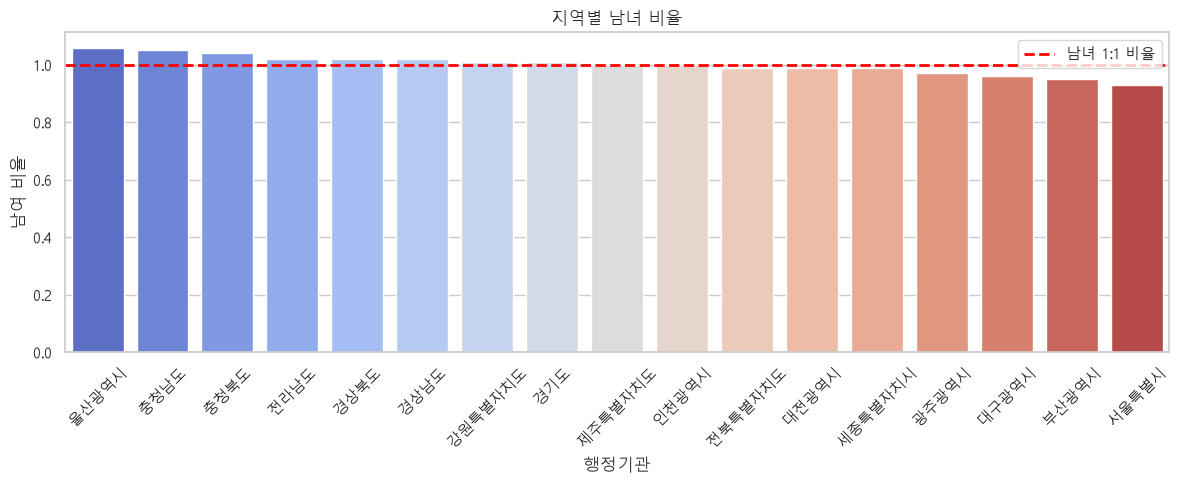

In [19]:
# 4-1-3. 남녀 비율 분석 Plot
plot_data = population.sort_values('남여 비율', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x='행정기관', y='남여 비율', hue='행정기관', palette='coolwarm', legend=False)
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='남녀 1:1 비율')
plt.title('지역별 남녀 비율')
plt.xlabel('행정기관')
plt.ylabel('남여 비율')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 4-1-4. 남자초과 / 여자초과 분석
display(population[['행정기관', '남여 비율', '남초여초']])

,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


In [21]:
# 4-1-5. 세대당 인구 평균보다 높은 지역
above_mean = population[population['세대당 인구'] > national_per_household].sort_values(
    '세대당 인구',
    ascending=False,
)

print(f'전국 평균 세대당 인구수: {national_per_household:.2f}')
display(above_mean[['행정기관', '세대당 인구']])

전국 평균 세대당 인구수: 2.12


,행정기관,세대당 인구
8,세종특별자치시,2.39
9,경기도,2.26
7,울산광역시,2.22
4,인천광역시,2.20
3,대구광역시,2.14
5,광주광역시,2.14
17,제주특별자치도,2.13


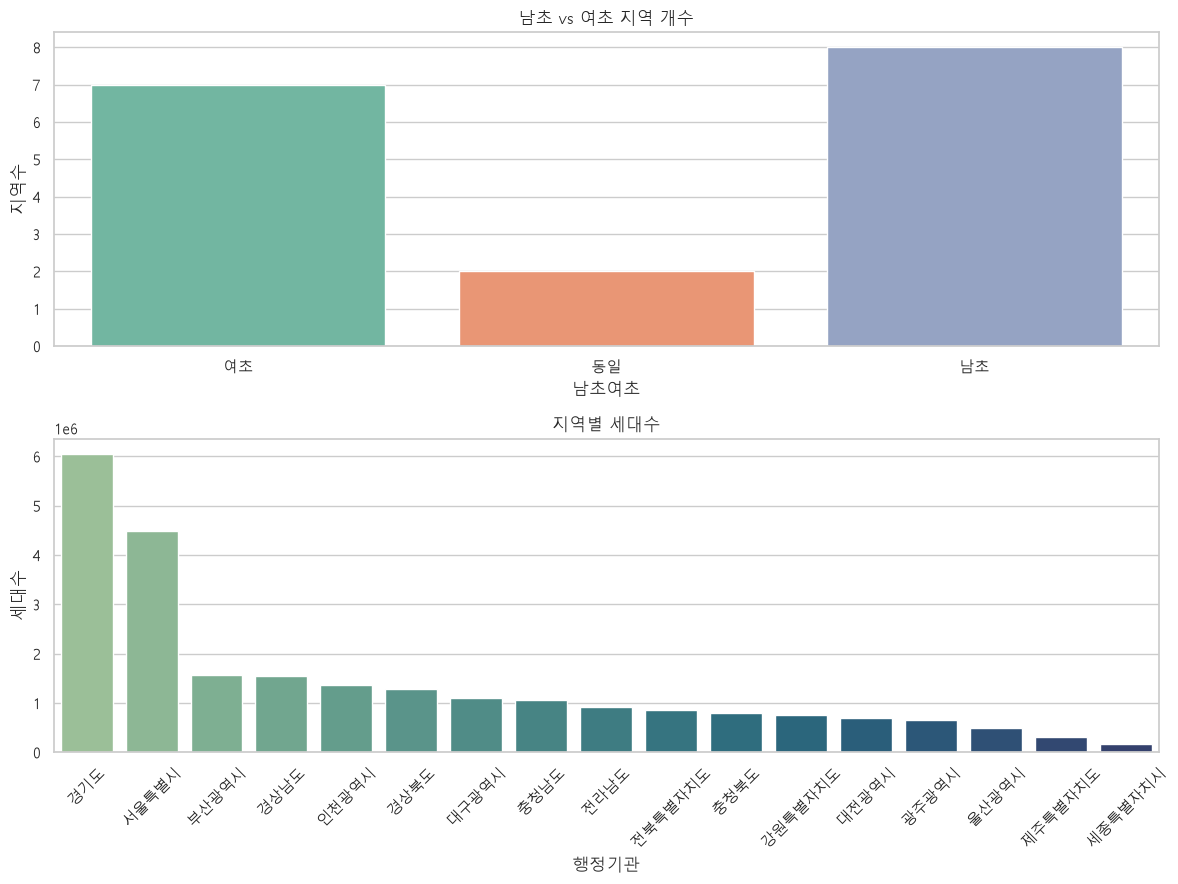

In [22]:
# 4-1-5. 남초 vs 여초 개수 Plot / 지역별 세대수 Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

sns.countplot(
    data=population,
    x='남초여초',
    order=['여초', '동일', '남초'],
    hue='남초여초',
    palette='Set2',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('남초 vs 여초 지역 개수')
axes[0].set_xlabel('남초여초')
axes[0].set_ylabel('지역수')

household_plot = population.sort_values('세대수', ascending=False)
sns.barplot(
    data=household_plot,
    x='행정기관',
    y='세대수',
    hue='행정기관',
    palette='crest',
    legend=False,
    ax=axes[1],
)
axes[1].set_title('지역별 세대수')
axes[1].set_xlabel('행정기관')
axes[1].set_ylabel('세대수')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()